In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

In [2]:
df_before_cleaning = pd.read_csv("/content/Pakistan Largest Ecommerce Dataset.csv")

/tmp/ipykernel_2280/2724739456.py:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_before_cleaning = pd.read_csv("/content/Pakistan Largest Ecommerce Dataset.csv")


In [3]:
df_before_cleaning

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df_before_cleaning.copy()

In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,cod,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,7-2016,FY17,1.0
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,cod,7/1/2016,Gross,240,2016.0,7.0,2016-7,7-2016,FY17,2.0
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,cod,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,7-2016,FY17,3.0
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,cod,7/1/2016,Net,360,2016.0,7.0,2016-7,7-2016,FY17,4.0
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,cod,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,7-2016,FY17,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df.dropna(how='all')
df

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,cod,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,7-2016,FY17,1.0
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,cod,7/1/2016,Gross,240,2016.0,7.0,2016-7,7-2016,FY17,2.0
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,cod,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,7-2016,FY17,3.0
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,cod,7/1/2016,Net,360,2016.0,7.0,2016-7,7-2016,FY17,4.0
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,cod,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,7-2016,FY17,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584519,905204.0,cod,8/28/2018,WOFSCE5AE00357AECDE,699.0,1.0,849.0,100562385,Women's Fashion,NaN,...,cod,8/28/2018,Valid,699,2018.0,8.0,2018-8,8-2018,FY19,115320.0
584520,905205.0,processing,8/28/2018,MATHUA5AF70A7D1E50A,35599.0,1.0,35899.0,100562386,Mobiles & Tablets,NaN,...,bankalfalah,8/28/2018,Gross,"35,599",2018.0,8.0,2018-8,8-2018,FY19,115326.0
584521,905206.0,processing,8/28/2018,MATSAM5B6D7208C6D30,129999.0,2.0,652178.0,100562387,Mobiles & Tablets,NaN,...,bankalfalah,8/28/2018,Gross,"259,998",2018.0,8.0,2018-7,8-2018,FY19,113474.0
584522,905207.0,processing,8/28/2018,MATSAM5B1509B4696EA,87300.0,2.0,652178.0,100562387,Mobiles & Tablets,NaN,...,bankalfalah,8/28/2018,Gross,"174,600",2018.0,8.0,2018-7,8-2018,FY19,113474.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584524 entries, 0 to 584523
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-null  o

In [8]:
df.isnull().sum()

,0
item_id,0
status,15
created_at,0
sku,20
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,164
sales_commission_code,137178


In [9]:
df = df.drop('sales_commission_code', axis=1)


In [10]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [11]:
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,0
discount_amount,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.replace(r'^\s*\\N\s*$', np.nan, regex=True)
df.isnull().sum()

,0
item_id,0
status,4
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,7833
discount_amount,0


In [14]:
df['category_name_1'] = df['category_name_1'].fillna('Others')
df = df.dropna(subset=['status'])

In [15]:
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,0
discount_amount,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584310 entries, 0 to 584313
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   item_id          584310 non-null  float64
 1   status           584310 non-null  object 
 2   created_at       584310 non-null  object 
 3   sku              584310 non-null  object 
 4   price            584310 non-null  float64
 5   qty_ordered      584310 non-null  float64
 6   grand_total      584310 non-null  float64
 7   increment_id     584310 non-null  object 
 8   category_name_1  584310 non-null  object 
 9   discount_amount  584310 non-null  float64
 10  payment_method   584310 non-null  object 
 11  Working Date     584310 non-null  object 
 12  BI Status        584310 non-null  object 
 13   MV              584310 non-null  object 
 14  Year             584310 non-null  float64
 15  Month            584310 non-null  float64
 16  Customer Since   584310 non-null  object 
 

In [18]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['Working Date'] = pd.to_datetime(df['Working Date'], errors='coerce')
df['Customer Since'] = pd.to_datetime(df['Customer Since'], format='%Y-%m', errors='coerce')

In [19]:
df['M-Y'] = df['M-Y'].astype(str).str.strip()

In [20]:
df['increment_id'] = pd.to_numeric(df['increment_id'], errors='coerce').astype('Int64')
df['Customer ID'] = pd.to_numeric(df['Customer ID'], errors='coerce').astype('Int64')
df['item_id'] = pd.to_numeric(df['item_id'], errors='coerce').astype('Int64')

In [21]:
df.columns = df.columns.str.strip()

In [22]:
df['MV'] = df['MV'].dropna().astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['MV'] = pd.to_numeric(df['MV'], errors='coerce')

In [23]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['Month'] = pd.to_numeric(df['Month'], errors='coerce').astype('Int64')
df['qty_ordered'] = pd.to_numeric(df['qty_ordered'], errors='coerce').astype('Int64')

In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 584310 entries, 0 to 584313
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   item_id          584310 non-null  Int64         
 1   status           584310 non-null  object        
 2   created_at       584310 non-null  datetime64[ns]
 3   sku              584310 non-null  object        
 4   price            584310 non-null  float64       
 5   qty_ordered      584310 non-null  Int64         
 6   grand_total      584310 non-null  float64       
 7   increment_id     584301 non-null  Int64         
 8   category_name_1  584310 non-null  object        
 9   discount_amount  584310 non-null  float64       
 10  payment_method   584310 non-null  object        
 11  Working Date     584310 non-null  datetime64[ns]
 12  BI Status        584310 non-null  object        
 13  MV               582096 non-null  float64       
 14  Year             584310 n

In [25]:
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
increment_id,9
category_name_1,0
discount_amount,0


In [26]:
df['MV'] = df['MV'].fillna(df['MV'].median())

In [27]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [28]:
df.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,0
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,0
discount_amount,0


In [29]:
df

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,discount_amount,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131,complete,2016-07-01,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,0.0,cod,2016-07-01,#REF!,1950.0,2016,7,2016-07-01,7-2016,FY17,1
1,211133,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,0.0,cod,2016-07-01,Gross,240.0,2016,7,2016-07-01,7-2016,FY17,2
2,211134,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,0.0,cod,2016-07-01,Gross,2450.0,2016,7,2016-07-01,7-2016,FY17,3
3,211135,complete,2016-07-01,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,300.0,cod,2016-07-01,Net,360.0,2016,7,2016-07-01,7-2016,FY17,4
4,211136,order_refunded,2016-07-01,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,0.0,cod,2016-07-01,Valid,1110.0,2016,7,2016-07-01,7-2016,FY17,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584296,905204,cod,2018-08-28,WOFSCE5AE00357AECDE,699.0,1,849.0,100562385,Women's Fashion,0.0,cod,2018-08-28,Valid,699.0,2018,8,2018-08-01,8-2018,FY19,115320
584297,905205,processing,2018-08-28,MATHUA5AF70A7D1E50A,35599.0,1,35899.0,100562386,Mobiles & Tablets,0.0,bankalfalah,2018-08-28,Gross,35599.0,2018,8,2018-08-01,8-2018,FY19,115326
584298,905206,processing,2018-08-28,MATSAM5B6D7208C6D30,129999.0,2,652178.0,100562387,Mobiles & Tablets,0.0,bankalfalah,2018-08-28,Gross,259998.0,2018,8,2018-07-01,8-2018,FY19,113474
584299,905207,processing,2018-08-28,MATSAM5B1509B4696EA,87300.0,2,652178.0,100562387,Mobiles & Tablets,0.0,bankalfalah,2018-08-28,Gross,174600.0,2018,8,2018-07-01,8-2018,FY19,113474


In [30]:
numeric_cols = ['price', 'qty_ordered', 'grand_total', 'discount_amount', 'MV']

In [31]:
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (count / len(df)) * 100

    outlier_summary.append({
        'Metric': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers Count': count,
        'Outliers %': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

         Metric     Min        Max  Lower Bound  Upper Bound  Outliers Count  Outliers %
          price     0.0  1012625.9     -5235.00       9685.0          105651       18.08
    qty_ordered     1.0     1000.0         1.00          1.0           79186       13.55
    grand_total -1594.0 17888000.0     -8135.50      16079.7           77086       13.19
discount_amount  -599.5    90300.0      -241.14        401.9          108963       18.65
             MV     0.0  8944000.0     -6502.50      11901.5          102982       17.62


In [32]:
negative_grand_total_count = (df['grand_total'] < 0).sum()
negative_discount_amount = (df['discount_amount'] < 0).sum()
prices_equal_to_zero = (df['price'] == 0).sum()
print(f"Number of negative values in 'grand_total': {negative_grand_total_count}")
print(f"Number of negative values in 'discount_amount': {negative_discount_amount}")
print(f"number of zeros in 'price': {prices_equal_to_zero}")

Number of negative values in 'grand_total': 76
Number of negative values in 'discount_amount': 3
number of zeros in 'price': 2214


In [33]:
# Remove zero prices and negative grand totals and discounts
df = df[(df['price'] > 0) & (df['grand_total'] >= 0) & (df['discount_amount'] >= 0)]
df.reset_index(drop=True, inplace=True)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582008 entries, 0 to 582007
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   item_id          582008 non-null  Int64         
 1   status           582008 non-null  object        
 2   created_at       582008 non-null  datetime64[ns]
 3   sku              582008 non-null  object        
 4   price            582008 non-null  float64       
 5   qty_ordered      582008 non-null  Int64         
 6   grand_total      582008 non-null  float64       
 7   increment_id     582008 non-null  Int64         
 8   category_name_1  582008 non-null  object        
 9   discount_amount  582008 non-null  float64       
 10  payment_method   582008 non-null  object        
 11  Working Date     582008 non-null  datetime64[ns]
 12  BI Status        582008 non-null  object        
 13  MV               582008 non-null  float64       
 14  Year             582

In [35]:
df

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,discount_amount,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131,complete,2016-07-01,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,0.0,cod,2016-07-01,#REF!,1950.0,2016,7,2016-07-01,7-2016,FY17,1
1,211133,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,0.0,cod,2016-07-01,Gross,240.0,2016,7,2016-07-01,7-2016,FY17,2
2,211134,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,0.0,cod,2016-07-01,Gross,2450.0,2016,7,2016-07-01,7-2016,FY17,3
3,211135,complete,2016-07-01,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,300.0,cod,2016-07-01,Net,360.0,2016,7,2016-07-01,7-2016,FY17,4
4,211136,order_refunded,2016-07-01,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,0.0,cod,2016-07-01,Valid,1110.0,2016,7,2016-07-01,7-2016,FY17,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582003,905204,cod,2018-08-28,WOFSCE5AE00357AECDE,699.0,1,849.0,100562385,Women's Fashion,0.0,cod,2018-08-28,Valid,699.0,2018,8,2018-08-01,8-2018,FY19,115320
582004,905205,processing,2018-08-28,MATHUA5AF70A7D1E50A,35599.0,1,35899.0,100562386,Mobiles & Tablets,0.0,bankalfalah,2018-08-28,Gross,35599.0,2018,8,2018-08-01,8-2018,FY19,115326
582005,905206,processing,2018-08-28,MATSAM5B6D7208C6D30,129999.0,2,652178.0,100562387,Mobiles & Tablets,0.0,bankalfalah,2018-08-28,Gross,259998.0,2018,8,2018-07-01,8-2018,FY19,113474
582006,905207,processing,2018-08-28,MATSAM5B1509B4696EA,87300.0,2,652178.0,100562387,Mobiles & Tablets,0.0,bankalfalah,2018-08-28,Gross,174600.0,2018,8,2018-07-01,8-2018,FY19,113474


In [36]:
extreme_orders = df[df['grand_total'] > 1000000]
print(f"Orders > 1,000,000: {len(extreme_orders)}")

Orders > 1,000,000: 17


In [37]:
print(df['grand_total'].nlargest(30).to_string())

239089    17888000.0
239090    17888000.0
239094    17888000.0
239095    17888000.0
239787    17888000.0
239788    17888000.0
199238     1315875.0
15856      1280473.0
15857      1280473.0
5699       1279980.0
949        1155966.0
190465     1039479.0
516330     1028751.0
516331     1028751.0
516332     1028751.0
516333     1028751.0
507218     1012625.9
184053      888065.0
184054      888065.0
184055      888065.0
184056      888065.0
184057      888065.0
184058      888065.0
184059      888065.0
16818       847024.0
16819       847024.0
16820       847024.0
16821       847024.0
16822       847024.0
16823       847024.0


In [38]:
df = df[df['grand_total'] != 17888000.0]

In [39]:
print(df['price'].nlargest(30).to_string())

507218    1012625.9
308921     515975.0
207119     479000.0
207190     479000.0
250585     479000.0
250586     479000.0
123927     330499.0
182756     330499.0
422389     320000.0
340323     307970.0
340403     307970.0
47326      300000.0
49622      300000.0
49658      300000.0
49960      300000.0
554148     291667.0
557339     291667.0
231857     289999.0
189772     265499.0
249664     244999.0
250514     244999.0
250515     244999.0
250520     244999.0
11486      235000.0
16821      235000.0
48245      235000.0
50283      235000.0
122883     235000.0
122885     235000.0
123406     235000.0


In [40]:
print(df['MV'].nlargest(30).to_string())

199238    1315875.0
5699      1279980.0
949       1155966.0
190465    1039479.0
507218    1012626.0
15856      866416.0
507220     815000.0
514078     638885.0
25498      569992.0
528200     555000.0
528207     555000.0
538258     555000.0
528133     529000.0
538253     526050.0
538426     526050.0
538429     526050.0
538255     519995.0
538439     519995.0
308921     515975.0
27994      507900.0
554706     499995.0
250514     489998.0
516333     489000.0
207119     479000.0
207190     479000.0
250585     479000.0
250586     479000.0
141447     475000.0
552262     472000.0
552643     472000.0


In [41]:
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (count / len(df)) * 100

    outlier_summary.append({
        'Metric': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers Count': count,
        'Outliers %': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

         Metric  Min       Max  Lower Bound  Upper Bound  Outliers Count  Outliers %
          price  0.1 1012625.9      -5340.5      9871.50          105257       18.09
    qty_ordered  1.0     502.0          1.0         1.00           78079       13.42
    grand_total  0.0 1315875.0      -8187.5     16176.50           76689       13.18
discount_amount  0.0   90300.0       -247.1       411.83          108363       18.62
             MV  0.0 1315875.0      -6502.5     11901.50          102968       17.69


In [42]:
text_cols = ['status', 'payment_method', 'category_name_1', 'BI Status']

for col in text_cols:
    df.loc[:, col] = df[col].astype(str).str.strip()

for col in text_cols:
    print(f"\n--- Unique values in {col} ---")
    print(df[col].unique())


--- Unique values in status ---
['complete' 'canceled' 'order_refunded' 'received' 'refund' 'closed'
 'fraud' 'holded' 'exchange' 'pending_paypal' 'paid' 'cod' 'pending'
 'processing' 'payment_review']

--- Unique values in payment_method ---
['cod' 'ublcreditcard' 'mygateway' 'customercredit' 'cashatdoorstep'
 'mcblite' 'internetbanking' 'marketingexpense' 'productcredit'
 'financesettlement' 'Payaxis' 'jazzvoucher' 'jazzwallet' 'Easypay'
 'Easypay_MA' 'easypay_voucher' 'bankalfalah' 'apg']

--- Unique values in category_name_1 ---
["Women's Fashion" 'Beauty & Grooming' 'Soghaat' 'Mobiles & Tablets'
 'Appliances' 'Home & Living' "Men's Fashion" 'Kids & Baby' 'Others'
 'Entertainment' 'Computing' 'Superstore' 'Health & Sports' 'Books'
 'School & Education']

--- Unique values in BI Status ---
['#REF!' 'Gross' 'Net' 'Valid']


In [43]:
ref_count = (df['BI Status'] == '#REF!').sum()
print(f"Rows with #REF! in BI Status: {ref_count}")

Rows with #REF! in BI Status: 1


In [44]:
print(df[df['BI Status'] == '#REF!'][['status', 'grand_total', 'BI Status']].head())

     status  grand_total BI Status
0  complete       1950.0     #REF!


In [45]:
df.loc[:, 'payment_method'] = df['payment_method'].str.lower()

df.loc[:, 'BI Status'] = df['BI Status'].replace('#REF!', 'Unknown')

print("\n--- Cleaned BI Status ---")
print(df['BI Status'].unique())

print("\n--- Cleaned Payment Methods ---")
print(df['payment_method'].unique())


--- Cleaned BI Status ---
['Unknown' 'Gross' 'Net' 'Valid']

--- Cleaned Payment Methods ---
['cod' 'ublcreditcard' 'mygateway' 'customercredit' 'cashatdoorstep'
 'mcblite' 'internetbanking' 'marketingexpense' 'productcredit'
 'financesettlement' 'payaxis' 'jazzvoucher' 'jazzwallet' 'easypay'
 'easypay_ma' 'easypay_voucher' 'bankalfalah' 'apg']


In [46]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

if exact_dupes > 0:
    df = df.drop_duplicates()

item_dupes = df.duplicated(subset=['increment_id', 'item_id']).sum()
print(f"Duplicate item entries within same order: {item_dupes}")

Exact duplicate rows: 0
Duplicate item entries within same order: 0


In [48]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)

In [49]:
df.head(30)

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,discount_amount,...,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID,status_clean
0,211131,complete,2016-07-01,kreations_YI 06-L,1950.00,1,1950.00,100147443,Women's Fashion,0.0,...,2016-07-01,Unknown,1950.0,2016,7,2016-07-01,7-2016,FY17,1,complete
1,211133,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.00,1,240.00,100147444,Beauty & Grooming,0.0,...,2016-07-01,Gross,240.0,2016,7,2016-07-01,7-2016,FY17,2,canceled
2,211134,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.00,1,2450.00,100147445,Women's Fashion,0.0,...,2016-07-01,Gross,2450.0,2016,7,2016-07-01,7-2016,FY17,3,canceled
3,211135,complete,2016-07-01,kcc_krone deal,360.00,1,60.00,100147446,Beauty & Grooming,300.0,...,2016-07-01,Net,360.0,2016,7,2016-07-01,7-2016,FY17,4,complete
4,211136,order_refunded,2016-07-01,BK7010400AG,555.00,2,1110.00,100147447,Soghaat,0.0,...,2016-07-01,Valid,1110.0,2016,7,2016-07-01,7-2016,FY17,5,refunded
5,211137,canceled,2016-07-01,UK_Namkino All In One 200 Gms,80.00,1,80.00,100147448,Soghaat,0.0,...,2016-07-01,Gross,80.0,2016,7,2016-07-01,7-2016,FY17,6,canceled
6,211138,complete,2016-07-01,kcc_krone deal,360.00,1,60.00,100147449,Beauty & Grooming,300.0,...,2016-07-01,Net,360.0,2016,7,2016-07-01,7-2016,FY17,7,complete
7,211139,complete,2016-07-01,UK_Namkino Mix Nimco 400 Gms,170.00,1,170.00,100147450,Soghaat,0.0,...,2016-07-01,Net,170.0,2016,7,2016-07-01,7-2016,FY17,6,complete
8,211140,canceled,2016-07-01,Apple iPhone 6S 64GB,96499.00,1,96499.00,100147451,Mobiles & Tablets,0.0,...,2016-07-01,Gross,96499.0,2016,7,2016-07-01,7-2016,FY17,8,canceled
9,211141,canceled,2016-07-01,Apple iPhone 6S 64GB,96499.00,1,96499.00,100147452,Mobiles & Tablets,0.0,...,2016-07-01,Gross,96499.0,2016,7,2016-07-01,7-2016,FY17,8,canceled


In [50]:
REALIZED_STATUSES = ['complete', 'received', 'closed']
df_sales = df[df['status'].isin(REALIZED_STATUSES)].copy()

booked_revenue = df['grand_total'].sum()
realized_revenue = df_sales['grand_total'].sum()
leakage_pct = (1 - realized_revenue / booked_revenue) * 100
cancel_rate = (df['status'] == 'canceled').mean() * 100
refund_rate = df['status'].isin(['refund', 'order_refunded']).mean() * 100
mean_aov = df_sales['grand_total'].mean()
median_aov = df_sales['grand_total'].median()

print(f"Booked revenue:     {booked_revenue:,.0f}")
print(f"Realized revenue:   {realized_revenue:,.0f}")
print(f"Revenue leakage:    {leakage_pct:.1f}%")
print(f"Cancellation rate:  {cancel_rate:.1f}%")
print(f"Refund rate:        {refund_rate:.1f}%")
print(f"Mean AOV:           {mean_aov:,.0f}")
print(f"Median AOV:         {median_aov:,.0f}")

Booked revenue:     4,877,212,083
Realized revenue:   1,574,543,910
Revenue leakage:    67.7%
Cancellation rate:  34.4%
Refund rate:        11.5%
Mean AOV:           5,068
Median AOV:         1,484


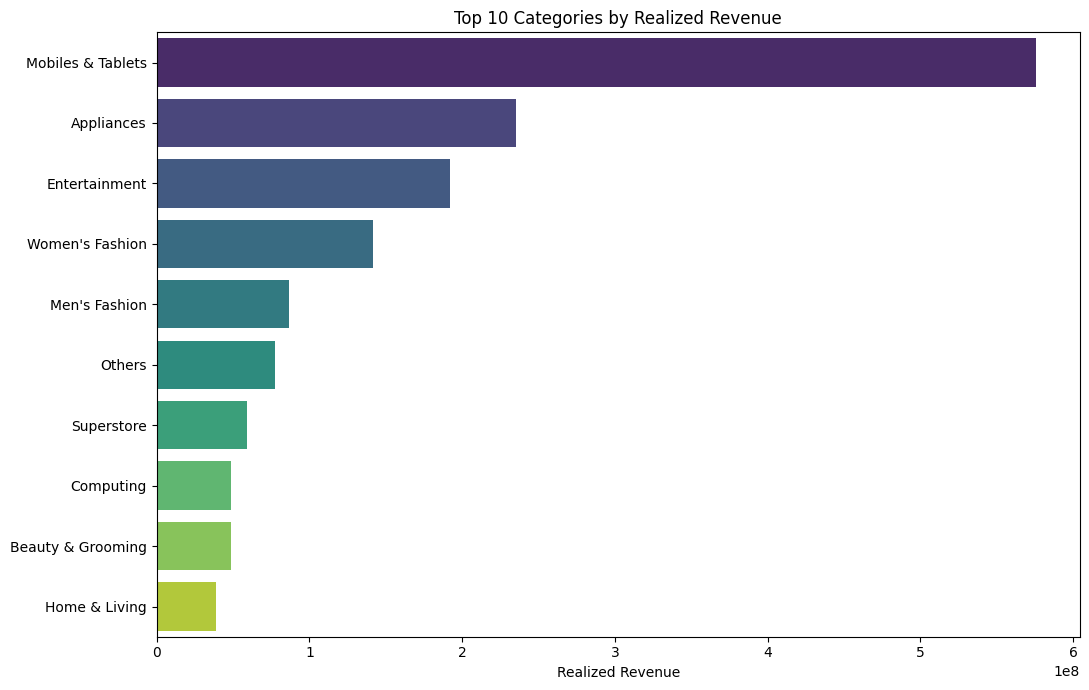

In [51]:
cat_rev = df_sales.groupby('category_name_1')['grand_total'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 7))
ax = sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, palette='viridis', legend=False)
plt.title('Top 10 Categories by Realized Revenue')
plt.xlabel('Realized Revenue')
plt.ylabel('')
plt.tight_layout()
plt.show()

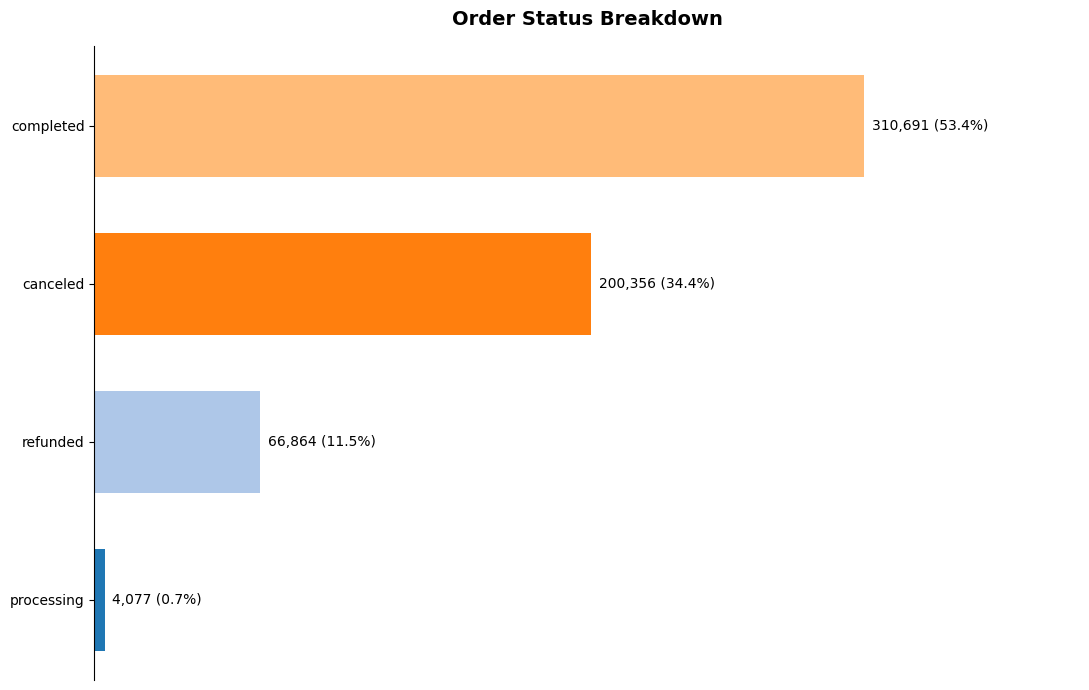

In [64]:
status_mapping = {
    'order_refunded': 'refunded',
    'refund': 'refunded',

    'received': 'completed',
    'complete': 'completed',
    'closed': 'completed',

    'pending_paypal': 'processing',
    'pending': 'processing',
    'payment_review': 'processing',
    'holded': 'processing',
    'cod': 'processing',
    'paid': 'processing'
}

df.loc[:, 'clean_status'] = df['status'].replace(status_mapping)

# Filter out 'fraud' and 'exchange' from the clean_status before value_counts
filtered_df = df[~df['clean_status'].isin(['fraud', 'exchange'])].copy()

status_df = filtered_df['clean_status'].value_counts().reset_index()
status_df.columns = ['Status', 'Orders']
status_df = status_df.sort_values(by='Orders', ascending=True)

total_orders = status_df['Orders'].sum()
status_df['Percentage'] = (status_df['Orders'] / total_orders) * 100

plt.figure(figsize=(11, 7))
colors = sns.color_palette('tab20', len(status_df))
bars = plt.barh(status_df['Status'], status_df['Orders'], color=colors, height=0.65)

for bar, pct, val in zip(bars, status_df['Percentage'], status_df['Orders']):
    plt.text(val + (status_df['Orders'].max() * 0.01), bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f} ({pct:.1f}%)', va='center', ha='left', fontsize=10)

plt.title('Order Status Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Orders', fontsize=11)
plt.xlim(0, status_df['Orders'].max() * 1.28)
plt.gca().xaxis.set_visible(False)
sns.despine(top=True, right=True, bottom=True)
plt.tight_layout()
plt.show()

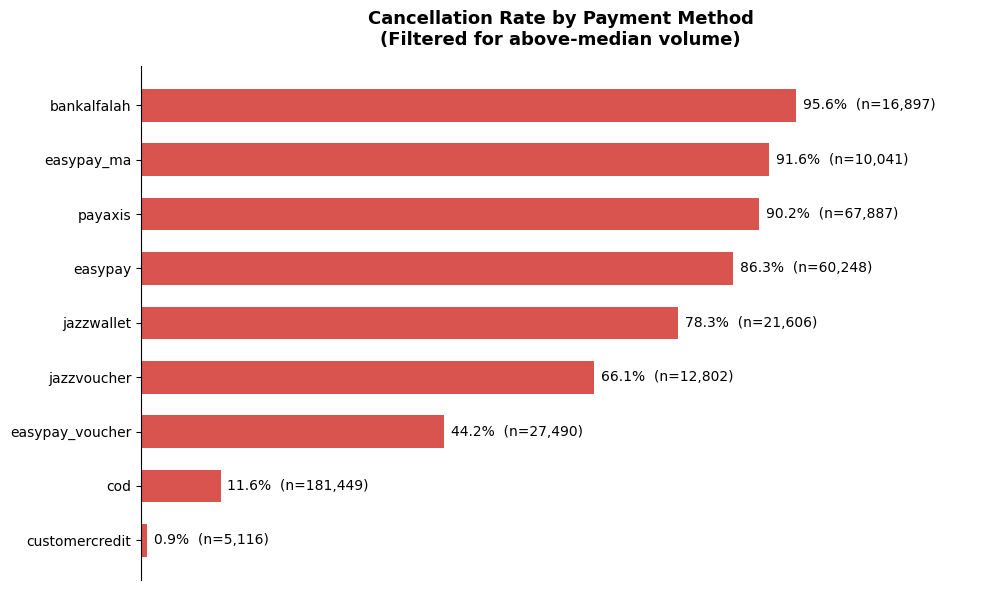

In [74]:
payment_risk = df.groupby('payment_method').agg(
    Total_Orders=('increment_id', 'nunique'),
    Canceled_Orders=('status', lambda x: (x == 'canceled').sum())
).reset_index()

# Filter above-median volume and calculate cancellation rate
payment_risk = payment_risk[payment_risk['Total_Orders'] > payment_risk['Total_Orders'].median()]
payment_risk['cancel_rate'] = (payment_risk['Canceled_Orders'] / payment_risk['Total_Orders']) * 100
payment_risk = payment_risk.sort_values('cancel_rate', ascending=True)

# 2. Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(payment_risk['payment_method'], payment_risk['cancel_rate'], color='#d9534f', height=0.6)

# 3. Add labels cleanly using direct column zip
for bar, rate, total in zip(bars, payment_risk['cancel_rate'], payment_risk['Total_Orders']):
    plt.text(rate + 1, bar.get_y() + bar.get_height() / 2,
             f"{rate:.1f}%  (n={total:,.0f})",
             va='center', ha='left', fontsize=10)

plt.title('Cancellation Rate by Payment Method\n(Filtered for above-median volume)', fontsize=13, fontweight='bold', pad=15)
plt.xlim(0, payment_risk['cancel_rate'].max() * 1.28)
plt.gca().xaxis.set_visible(False)
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout()
plt.show()

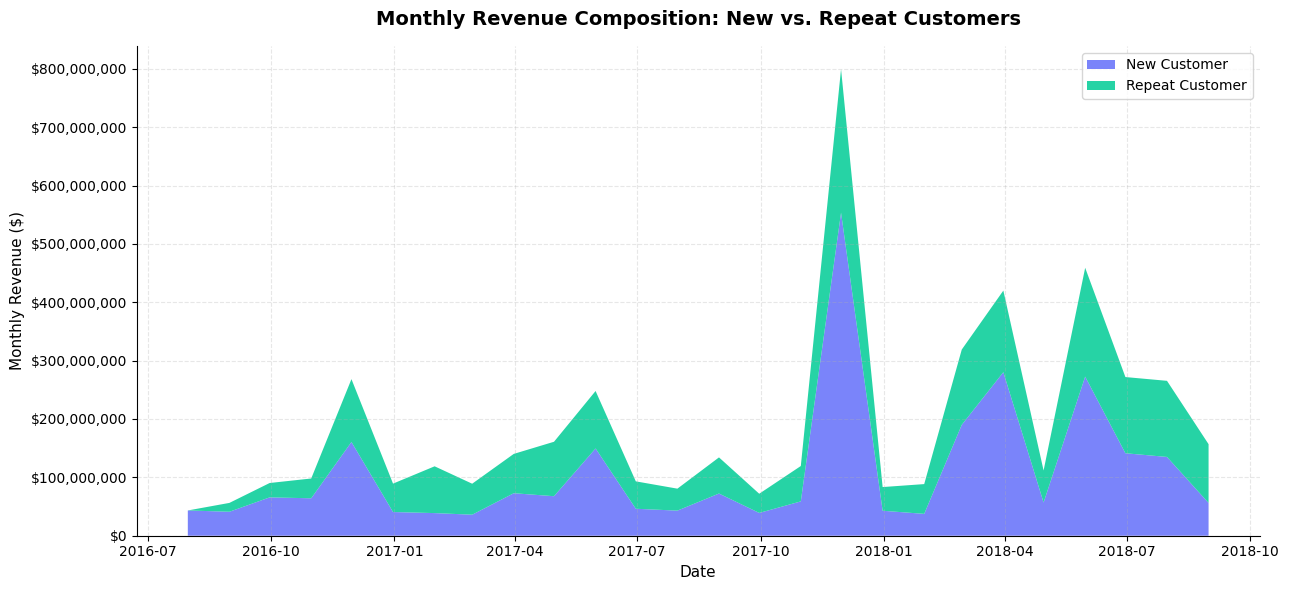

In [75]:
plot_data = df.copy()
plot_data['created_date'] = pd.to_datetime(plot_data['created_at'])
plot_data['join_date'] = pd.to_datetime(plot_data['Customer Since'])

plot_data['Order_M_Y'] = plot_data['created_date'].dt.to_period('M')
plot_data['Join_M_Y'] = plot_data['join_date'].dt.to_period('M')
plot_data['Customer_Type'] = (plot_data['Order_M_Y'] == plot_data['Join_M_Y']).map(
    {True: 'New Customer', False: 'Repeat Customer'}
)

monthly_cohort = plot_data.groupby(
    [pd.Grouper(key='created_date', freq='ME'), 'Customer_Type']
)['grand_total'].sum().unstack(fill_value=0)

plt.figure(figsize=(13, 6))
plt.stackplot(
    monthly_cohort.index,
    monthly_cohort['New Customer'],
    monthly_cohort['Repeat Customer'],
    labels=['New Customer', 'Repeat Customer'],
    colors=['#636efa', '#00cc96'],
    alpha=0.85
)

plt.title('Monthly Revenue Composition: New vs. Repeat Customers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Monthly Revenue ($)', fontsize=11)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

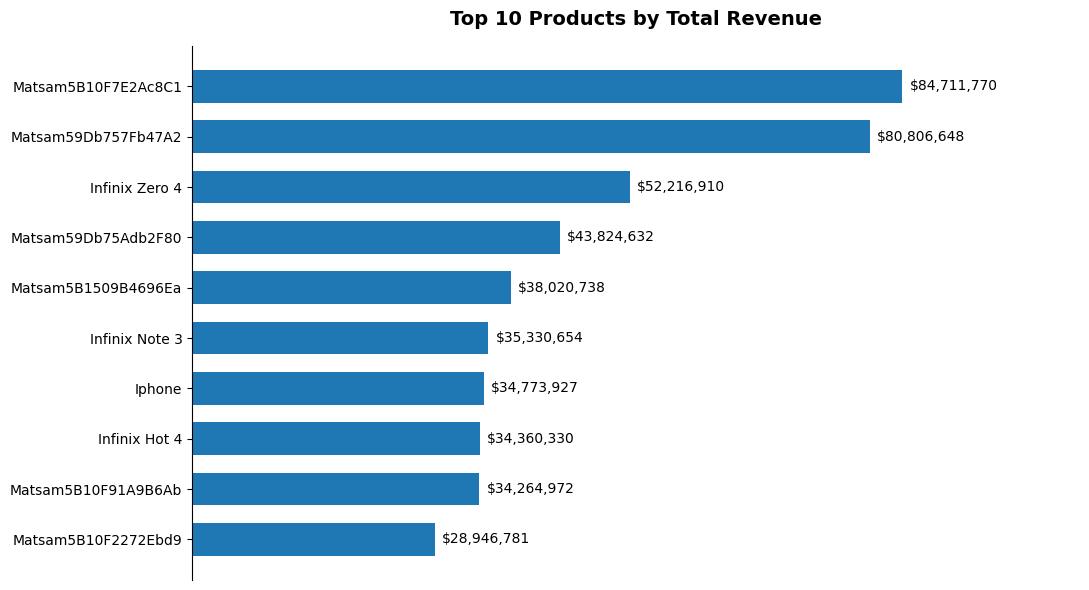

In [76]:
plot_df = df.copy()
plot_df['Product_Name'] = (
    plot_df['sku']
    .astype(str)
    .str.split('-')
    .str[0]
    .str.replace('_', ' ')
    .str.title()
)

top_products = (
    plot_df.groupby('Product_Name')['grand_total']
    .sum()
    .reset_index()
    .sort_values(by='grand_total', ascending=True)
    .tail(10)
)

plt.figure(figsize=(11, 6))
bars = plt.barh(top_products['Product_Name'], top_products['grand_total'], color='#1f77b4', height=0.65)

for bar, val in zip(bars, top_products['grand_total']):
    plt.text(val + (top_products['grand_total'].max() * 0.01), bar.get_y() + bar.get_height() / 2,
             f'${val:,.0f}', va='center', ha='left', fontsize=10)

plt.title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, top_products['grand_total'].max() * 1.25)
plt.gca().xaxis.set_visible(False)
sns.despine(top=True, right=True, bottom=True)
plt.tight_layout()
plt.show()

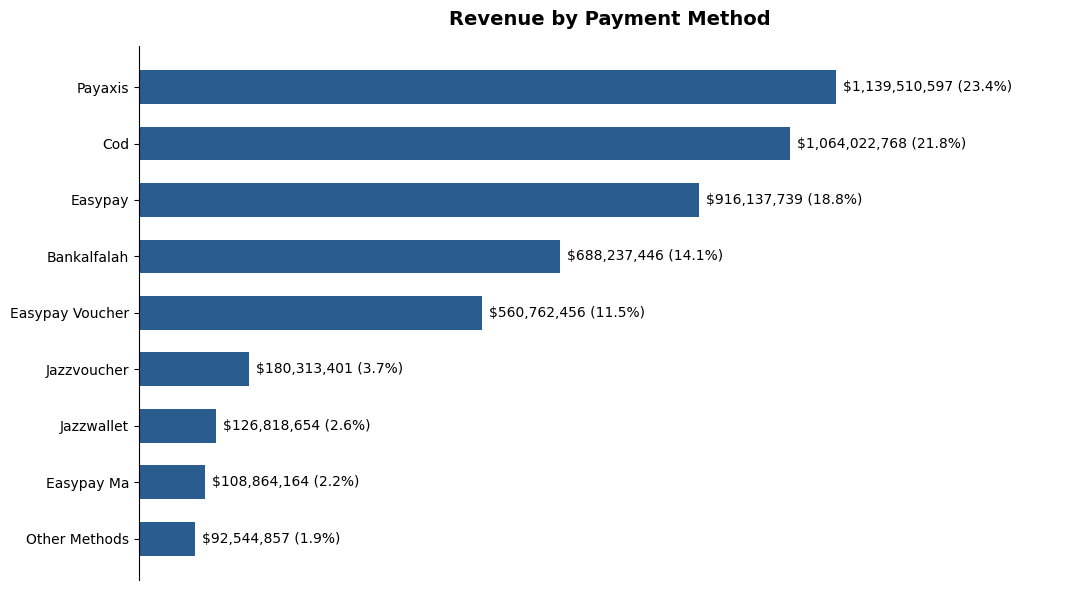

In [78]:
plot_df = df.copy()
plot_df['Payment_Channel'] = (
    plot_df['payment_method']
    .astype(str)
    .str.replace('_', ' ')
    .str.strip()
    .str.title()
)

# 2. Calculate Revenue & Share Percentage
payment_summary = (
    plot_df.groupby('Payment_Channel')['grand_total']
    .sum()
    .reset_index(name='Revenue')
)
total_revenue = payment_summary['Revenue'].sum()
payment_summary['share_pct'] = (payment_summary['Revenue'] / total_revenue) * 100

# Group long tail into 'Other Methods'
if len(payment_summary) > 8:
    top_channels = payment_summary.nlargest(8, 'Revenue')
    other_revenue = payment_summary.loc[~payment_summary.index.isin(top_channels.index), 'Revenue'].sum()
    other_share = (other_revenue / total_revenue) * 100

    other_row = pd.DataFrame([{
        'Payment_Channel': 'Other Methods',
        'Revenue': other_revenue,
        'share_pct': other_share
    }])
    payment_summary = pd.concat([top_channels, other_row], ignore_index=True)

payment_summary = payment_summary.sort_values('Revenue', ascending=True)

# 3. Plot
plt.figure(figsize=(11, 6))
bars = plt.barh(payment_summary['Payment_Channel'], payment_summary['Revenue'], color='#2b5c8f', height=0.6)

# 4. Direct label zip (avoids itertuples attribute issues)
for bar, rev, share in zip(bars, payment_summary['Revenue'], payment_summary['share_pct']):
    plt.text(rev + (payment_summary['Revenue'].max() * 0.01), bar.get_y() + bar.get_height() / 2,
             f"${rev:,.0f} ({share:.1f}%)",
             va='center', ha='left', fontsize=10)

plt.title('Revenue by Payment Method', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, payment_summary['Revenue'].max() * 1.35)
plt.gca().xaxis.set_visible(False)
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout()
plt.show()

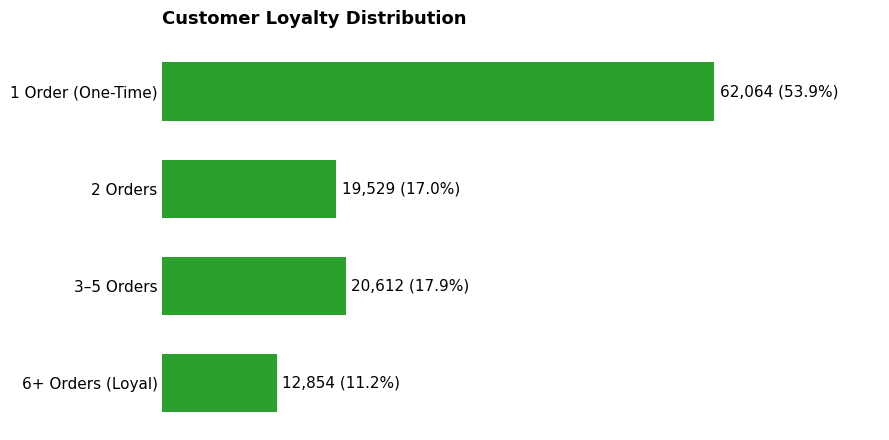

In [79]:
order_counts = (
    df.groupby('Customer ID')['increment_id']
    .nunique()
    .reset_index(name='Total_Orders')
)

order_counts['Order_Tier'] = pd.cut(
    order_counts['Total_Orders'],
    bins=[0, 1, 2, 5, float('inf')],
    labels=['1 Order (One-Time)', '2 Orders', '3–5 Orders', '6+ Orders (Loyal)']
)

loyalty_df = (
    order_counts['Order_Tier']
    .value_counts(sort=False)
    .reset_index()
)
loyalty_df.columns = ['Tier', 'Customers']

total_cust = loyalty_df['Customers'].sum()
loyalty_df['share_pct'] = (loyalty_df['Customers'] / total_cust) * 100

# 2. Plotting with Matplotlib
plt.figure(figsize=(9, 4.5))

# Inverted order so '1 Order (One-Time)' appears at the top
bars = plt.barh(
    loyalty_df['Tier'][::-1],
    loyalty_df['Customers'][::-1],
    color='#2ca02c',
    height=0.6
)

# 3. Add direct data labels (Count + Share %)
for bar, count, share in zip(bars, loyalty_df['Customers'][::-1], loyalty_df['share_pct'][::-1]):
    plt.text(
        count + (loyalty_df['Customers'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{count:,.0f} ({share:.1f}%)",
        va='center',
        ha='left',
        fontsize=11
    )

# 4. Clean layout styling
plt.title('Customer Loyalty Distribution', fontsize=13, fontweight='bold', pad=15, loc='left')
plt.xlim(0, loyalty_df['Customers'].max() * 1.3)
plt.gca().xaxis.set_visible(False)
plt.gca().spines[['top', 'right', 'bottom', 'left']].set_visible(False)
plt.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()